# ViT v6 — Radiology Report Text Encoder + v3/v5 Ensemble
**Goal**: push test AUROC above 0.80 by adding the single largest untapped signal — the radiologist-written findings and impressions from MIMIC-CXR reports.

**Strategy** (designed around what failed in v4/v5):
1. Load MIMIC-CXR reports (`.txt` per study) and extract `FINDINGS` + `IMPRESSION` sections.
2. Encode with a frozen biomedical BERT (default: Bio_ClinicalBERT; upgrade: CXR-BERT-general).
3. Pre-compute frozen XRV DenseNet121 image features (same cohort/split as v5).
4. Train a small **trimodal fusion MLP** (text ⊕ image ⊕ tabular) per fold in 5-fold CV.
5. Build an OOF-trained logistic regression stacker using `[p_v3, p_v5, p_v6, p_xrv_native_prior, top-6 EHR]` — avoids the val-overfitting we hit in v4.
6. Report bootstrap 95% CI on the final test AUROC.

## 1. Install & imports

In [1]:
# Uncomment on first run, then comment out
# !pip install -q torchxrayvision scikit-image transformers tokenizers accelerate

In [2]:
import os, re, json, random, warnings, copy, time, gzip
from pathlib import Path
from typing import Optional
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
from PIL import Image

# repro
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
DEVICE = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
print('Device:', DEVICE)
warnings.filterwarnings('ignore')

Device: mps


## 2. Paths, cohort, split (identical to v3/v5)

In [3]:
# Auto-detect project root from notebook location.
PROJ = Path.cwd().parent if Path.cwd().name == 'code' else Path.cwd()
DATA = PROJ / 'data'
RES  = PROJ / 'results'
RES.mkdir(parents=True, exist_ok=True)

COHORT_CSV   = DATA / 'mimic_ed_cxr_pneumonia_multimodal_cohort.csv'
IMG_ROOT     = DATA / 'files'
REPORTS_ROOT: Optional[Path] = DATA / 'reports'   # extracted mimic-cxr-reports.zip

# Sanity check
for p in (DATA, IMG_ROOT, COHORT_CSV, REPORTS_ROOT, RES):
    assert p.exists(), f'missing: {p}'
print('PROJ           :', PROJ)
print('cohort         :', COHORT_CSV.exists())
print('image root     :', IMG_ROOT.exists())
print('reports root   :', REPORTS_ROOT, REPORTS_ROOT.exists())


PROJ           : /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj
cohort         : True
image root     : True
reports root   : /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/data/reports True


In [4]:
df = pd.read_csv(COHORT_CSV)
print('cohort rows:', len(df), '| prevalence:', df['Pneumonia'].mean().round(3))

def _img_path(row):
    pid, sid, did = int(row['subject_id']), int(row['study_id']), row['dicom_id']
    p = f'p{str(pid)[:2]}'
    return IMG_ROOT / p / f'p{pid}' / f's{sid}' / f'{did}.jpg'

df['img_path'] = df.apply(_img_path, axis=1)
df = df[df['img_path'].apply(lambda p: Path(p).exists())].reset_index(drop=True)
print('with image on disk:', len(df))

# Same 70/15/15 stratified split as v2/v3/v5 (SEED=42)
trainval_df, test_df = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df['Pneumonia']
)
train_df, val_df = train_test_split(
    trainval_df, test_size=0.15/0.85, random_state=SEED,
    stratify=trainval_df['Pneumonia']
)
print('train/val/test:', len(train_df), len(val_df), len(test_df))
print('test prev:', test_df['Pneumonia'].mean().round(3))

cohort rows: 1601 | prevalence: 0.328
with image on disk: 1601
train/val/test: 1119 241 241
test prev: 0.328


## 3. Load radiology reports (local preferred, downloader as fallback)

In [5]:
# ---- 3.1 Section extraction from raw MIMIC-CXR reports ----
SECTION_HEADERS = ('FINDINGS', 'IMPRESSION')
HEADER_RE = re.compile(
    r'^\s*(FINAL REPORT|FINDINGS|IMPRESSION|CONCLUSION|INDICATION|HISTORY|COMPARISON|'
    r'TECHNIQUE|EXAMINATION|REASON FOR EXAM|WET READ|CLINICAL HISTORY|NOTIFICATION)\s*:',
    re.IGNORECASE | re.MULTILINE,
)

def extract_sections(raw_text: str) -> str:
    '''Return the FINDINGS and IMPRESSION text, or the whole body as a fallback.'''
    if not isinstance(raw_text, str) or not raw_text.strip():
        return ''
    # find all header positions
    matches = list(HEADER_RE.finditer(raw_text))
    if not matches:
        return raw_text.strip()[:2000]
    sections = {}
    for i, m in enumerate(matches):
        name = m.group(1).upper()
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(raw_text)
        sections.setdefault(name, '')
        sections[name] += raw_text[start:end].strip() + '\n'
    # Prefer IMPRESSION + FINDINGS
    ordered = []
    for key in ('IMPRESSION', 'FINDINGS'):
        if key in sections:
            ordered.append(f'{key}: ' + sections[key].strip())
    if ordered:
        return '\n'.join(ordered)[:4000]
    # fallback: use any section body we found
    return '\n'.join(f'{k}: {v.strip()}' for k, v in sections.items())[:4000]

In [6]:
# ---- 3.2 Per-study report loader (local read) ----
# Standard mimic-cxr-reports.zip layout: <REPORTS_ROOT>/pXX/pXXXXXX/sXXXXX.txt
REPORT_CACHE = RES / 'mimic_cxr_reports_cohort.csv'

def local_report_path(root: Path, pid: int, sid: int) -> Path:
    # Try the common layout first, then the alternate one with a 'files/' prefix.
    candidates = [
        root / f'p{str(pid)[:2]}' / f'p{pid}' / f's{sid}.txt',
        root / 'files' / f'p{str(pid)[:2]}' / f'p{pid}' / f's{sid}.txt',
    ]
    for c in candidates:
        if c.exists():
            return c
    return candidates[0]  # return the expected path even if it's missing

def build_report_cache(df_all):
    if REPORT_CACHE.exists():
        print('cache found ->', REPORT_CACHE)
        return pd.read_csv(REPORT_CACHE)
    if REPORTS_ROOT is None or not REPORTS_ROOT.exists():
        raise RuntimeError(f'REPORTS_ROOT not set or missing: {REPORTS_ROOT}')
    rows, missing = [], 0
    t0 = time.time()
    for i, r in df_all.iterrows():
        pid, sid = int(r['subject_id']), int(r['study_id'])
        p = local_report_path(REPORTS_ROOT, pid, sid)
        if not p.exists():
            missing += 1
            continue
        txt = p.read_text(errors='ignore')
        rows.append({'subject_id': pid, 'study_id': sid,
                     'raw_report': txt, 'sections': extract_sections(txt)})
        if (i + 1) % 400 == 0:
            print(f'  {i+1}/{len(df_all)} ({time.time()-t0:.1f}s)')
    out = pd.DataFrame(rows)
    out.to_csv(REPORT_CACHE, index=False)
    print(f'cached {len(out)} reports ({missing} missing) -> {REPORT_CACHE}')
    return out

rep_df = build_report_cache(df)
rep_df['sections'] = rep_df['sections'].fillna('').astype(str)
df_r = df.merge(rep_df[['subject_id', 'study_id', 'sections']],
                on=['subject_id', 'study_id'], how='left')
df_r['sections'] = df_r['sections'].fillna('').astype(str)
print('reports attached :', (df_r['sections'].str.len() > 0).sum(), '/', len(df_r))
print('avg section length:', round(df_r['sections'].str.len().mean(), 1))


cache found -> /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/mimic_cxr_reports_cohort.csv
reports attached : 1601 / 1601
avg section length: 383.1


In [7]:
# Re-apply the same split but on df_r so row order matches
df_r = df_r.sort_values(['subject_id', 'study_id']).reset_index(drop=True)
trainval_df, test_df = train_test_split(
    df_r, test_size=0.15, random_state=SEED, stratify=df_r['Pneumonia']
)
train_df, val_df = train_test_split(
    trainval_df, test_size=0.15/0.85, random_state=SEED,
    stratify=trainval_df['Pneumonia']
)
print('train/val/test with reports:', len(train_df), len(val_df), len(test_df))

train/val/test with reports: 1119 241 241


## 4. Text encoder — frozen [CLS] embeddings

In [8]:
# ---- 4.1 Choose the text backbone ----
# Default: Bio_ClinicalBERT (broadly available, no extra license steps).
# Upgrade (recommended if accessible): microsoft/BiomedVLP-CXR-BERT-general
#   -- pretrained specifically on MIMIC-CXR reports.
TEXT_MODEL_ID = 'emilyalsentzer/Bio_ClinicalBERT'
# TEXT_MODEL_ID = 'microsoft/BiomedVLP-CXR-BERT-general'  # try this for +0.01-0.03
TEXT_MAX_LEN = 256

from transformers import AutoTokenizer, AutoModel
tok = AutoTokenizer.from_pretrained(TEXT_MODEL_ID)
text_model = AutoModel.from_pretrained(TEXT_MODEL_ID).to(DEVICE).eval()
for p in text_model.parameters():
    p.requires_grad = False
print('text encoder:', TEXT_MODEL_ID, '|', sum(p.numel() for p in text_model.parameters())/1e6, 'M params')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


text encoder: emilyalsentzer/Bio_ClinicalBERT | 108.310272 M params


In [9]:
# ---- 4.2 Compute [CLS] embeddings for the entire cohort (cached) ----
TEXT_EMB_PATH = RES / 'v6_text_cls_embeddings.npz'
TEXT_EMB_DIM = text_model.config.hidden_size  # 768

@torch.no_grad()
def encode_texts(texts, batch_size=16):
    feats = np.zeros((len(texts), TEXT_EMB_DIM), dtype=np.float32)
    for s in range(0, len(texts), batch_size):
        e = min(s + batch_size, len(texts))
        batch = [t if isinstance(t, str) and len(t) > 0 else 'NO REPORT' for t in texts[s:e]]
        enc = tok(batch, padding=True, truncation=True,
                  max_length=TEXT_MAX_LEN, return_tensors='pt').to(DEVICE)
        out = text_model(**enc)
        # mean-pooled token embedding (robust to BERT variants without [CLS] pooler)
        mask = enc['attention_mask'].unsqueeze(-1).float()
        pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1)
        feats[s:e] = pooled.cpu().numpy()
    return feats

if TEXT_EMB_PATH.exists():
    npz = np.load(TEXT_EMB_PATH, allow_pickle=True)
    text_feats_all = npz['X']; text_ids_all = npz['ids']
    print('loaded cached text embeddings:', text_feats_all.shape)
else:
    t0 = time.time()
    text_feats_all = encode_texts(df_r['sections'].tolist())
    text_ids_all = df_r['study_id'].astype(int).values
    np.savez(TEXT_EMB_PATH, X=text_feats_all, ids=text_ids_all)
    print(f'encoded {len(df_r)} reports in {time.time()-t0:.1f}s; saved -> {TEXT_EMB_PATH}')
text_idx = {int(s): i for i, s in enumerate(text_ids_all)}

loaded cached text embeddings: (1601, 768)


## 5. Image encoder — frozen XRV DenseNet121 features + native pneumonia prior

In [10]:
import torchxrayvision as xrv
import skimage, skimage.io

XRV_WEIGHTS = 'densenet121-res224-all'
xrv_model = xrv.models.DenseNet(weights=XRV_WEIGHTS).to(DEVICE).eval()
for p in xrv_model.parameters():
    p.requires_grad = False
PNEUMONIA_IDX = xrv.datasets.default_pathologies.index('Pneumonia')
print('XRV loaded.  feat dim = 1024  |  Pneumonia head idx =', PNEUMONIA_IDX)

XRV loaded.  feat dim = 1024  |  Pneumonia head idx = 8


In [11]:
# XRV expects 1-channel, [-1024, 1024] range, 224x224
from torchvision import transforms as T

class XRVTransform:
    def __init__(self, size=224):
        self.size = size
        self.tx = T.Compose([
            T.Resize((size, size)),
            T.Grayscale(num_output_channels=1),
        ])
    def __call__(self, img_path: str) -> torch.Tensor:
        img = Image.open(img_path).convert('RGB')
        img = self.tx(img)
        arr = np.array(img, dtype=np.float32)
        arr = (arr / 255.0) * 2048.0 - 1024.0  # [-1024, 1024]
        arr = arr[None, :, :]  # 1xHxW
        return torch.from_numpy(arr)

xrv_tx = XRVTransform(224)

In [12]:
# ---- 5.2 Compute frozen XRV features + native pneumonia prior for full cohort ----
IMG_EMB_PATH = RES / 'v6_xrv_feat_and_prior.npz'

class FlatImgDataset(Dataset):
    def __init__(self, df, tx):
        self.paths = df['img_path'].astype(str).tolist(); self.tx = tx
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tx(self.paths[i])

@torch.no_grad()
def extract_xrv(df_sub, batch_size=32):
    ds = FlatImgDataset(df_sub, xrv_tx)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    feats = np.zeros((len(ds), 1024), dtype=np.float32)
    priors = np.zeros(len(ds), dtype=np.float32)
    i = 0
    for batch in dl:
        batch = batch.to(DEVICE)
        f = xrv_model.features2(batch)         # (B, 1024)
        logits = xrv_model.classifier(f)       # (B, 18)
        p = torch.sigmoid(logits[:, PNEUMONIA_IDX])
        b = batch.size(0)
        feats[i:i+b] = f.cpu().numpy()
        priors[i:i+b] = p.cpu().numpy()
        i += b
    return feats, priors

if IMG_EMB_PATH.exists():
    npz = np.load(IMG_EMB_PATH)
    img_feats_all = npz['X']; img_prior_all = npz['prior']; img_ids_all = npz['ids']
    print('loaded cached image features:', img_feats_all.shape)
else:
    t0 = time.time()
    img_feats_all, img_prior_all = extract_xrv(df_r)
    img_ids_all = df_r['study_id'].astype(int).values
    np.savez(IMG_EMB_PATH, X=img_feats_all, prior=img_prior_all, ids=img_ids_all)
    print(f'extracted in {time.time()-t0:.1f}s')
img_idx = {int(s): i for i, s in enumerate(img_ids_all)}
print('XRV-native Pneumonia prior AUROC on the full cohort (sanity):',
      round(roc_auc_score(df_r['Pneumonia'].values, img_prior_all), 4))

loaded cached image features: (1601, 1024)
XRV-native Pneumonia prior AUROC on the full cohort (sanity): 0.7244


## 6. Tabular preprocessing (same 15 EHR features as v2/v3/v5)

In [13]:
EHR_COLS = [
    'age','gender','triage_temperature','triage_heartrate','triage_resprate',
    'triage_o2sat','triage_sbp','triage_dbp','triage_acuity',
    'chiefcom_shortness_of_breath','chiefcom_cough','chiefcom_fever_chills',
    'cci_Pulmonary','cci_CHF','score_CCI'
]

def make_ehr_matrix(df_sub, scaler=None, imputer=None, fit=False):
    X = df_sub[EHR_COLS].copy()
    X['gender'] = (X['gender'].astype(str).str.upper() == 'M').astype(float)
    X = X.apply(pd.to_numeric, errors='coerce')
    if fit:
        imputer = SimpleImputer(strategy='median').fit(X.values)
        Xi = imputer.transform(X.values)
        scaler = StandardScaler().fit(Xi)
        Xs = scaler.transform(Xi)
    else:
        Xi = imputer.transform(X.values)
        Xs = scaler.transform(Xi)
    return Xs.astype(np.float32), scaler, imputer

## 7. Trimodal fusion MLP + 5-fold CV (test held out)

In [14]:
class TrimodalHead(nn.Module):
    '''Frozen text [CLS] (768) + frozen XRV img (1024) + EHR MLP (64) -> logit.'''
    def __init__(self, text_dim=768, img_dim=1024, ehr_dim=15,
                 ehr_hidden=128, ehr_out=64,
                 head_hidden=256, dropout=0.3):
        super().__init__()
        self.ehr = nn.Sequential(
            nn.Linear(ehr_dim, ehr_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(ehr_hidden, ehr_out), nn.ReLU(),
        )
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, 256), nn.ReLU(), nn.Dropout(dropout),
        )
        self.img_proj = nn.Sequential(
            nn.Linear(img_dim, 256), nn.ReLU(), nn.Dropout(dropout),
        )
        fused_in = 256 + 256 + ehr_out
        self.head = nn.Sequential(
            nn.Linear(fused_in, head_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(head_hidden, 1),
        )
    def forward(self, t, i, e):
        return self.head(torch.cat([self.text_proj(t), self.img_proj(i), self.ehr(e)],
                                    dim=1)).squeeze(-1)

In [15]:
# ---- 7.1 Helpers to materialise feature tensors for a df slice ----
def stack_feats(df_sub):
    s = df_sub['study_id'].astype(int).values
    T_ = np.stack([text_feats_all[text_idx[int(x)]] for x in s]).astype(np.float32)
    I_ = np.stack([img_feats_all[img_idx[int(x)]]  for x in s]).astype(np.float32)
    prior = np.array([img_prior_all[img_idx[int(x)]] for x in s], dtype=np.float32)
    return T_, I_, prior

def train_one_fold(train_idx, val_idx, df_trainval, epochs=25,
                   lr=3e-4, wd=1e-4, batch=64, verbose=False):
    df_tr = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_va = df_trainval.iloc[val_idx].reset_index(drop=True)
    E_tr, scaler, imputer = make_ehr_matrix(df_tr, fit=True)
    E_va, *_ = make_ehr_matrix(df_va, scaler=scaler, imputer=imputer)
    T_tr, I_tr, _ = stack_feats(df_tr)
    T_va, I_va, _ = stack_feats(df_va)
    y_tr = df_tr['Pneumonia'].values.astype(np.float32)
    y_va = df_va['Pneumonia'].values.astype(np.float32)
    # tensors
    T_tr_t = torch.from_numpy(T_tr).to(DEVICE)
    I_tr_t = torch.from_numpy(I_tr).to(DEVICE)
    E_tr_t = torch.from_numpy(E_tr).to(DEVICE)
    y_tr_t = torch.from_numpy(y_tr).to(DEVICE)
    T_va_t = torch.from_numpy(T_va).to(DEVICE)
    I_va_t = torch.from_numpy(I_va).to(DEVICE)
    E_va_t = torch.from_numpy(E_va).to(DEVICE)
    model = TrimodalHead(ehr_dim=E_tr.shape[1]).to(DEVICE)
    pos = y_tr.sum(); neg = len(y_tr) - pos
    pw = torch.tensor(max(neg, 1)/max(pos, 1), device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val = -1.0; best_state = None
    n = len(y_tr)
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for s in range(0, n, batch):
            idx = perm[s:s+batch]
            opt.zero_grad()
            out = model(T_tr_t[idx], I_tr_t[idx], E_tr_t[idx])
            loss = loss_fn(out, y_tr_t[idx])
            loss.backward(); opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            p_va = torch.sigmoid(model(T_va_t, I_va_t, E_va_t)).cpu().numpy()
        auc = roc_auc_score(y_va, p_va)
        if auc > best_val:
            best_val = auc; best_state = copy.deepcopy(model.state_dict())
        if verbose:
            print(f'  ep{ep:02d} val_auc={auc:.4f}')
    model.load_state_dict(best_state)
    return model, scaler, imputer, best_val

In [16]:
# ---- 7.2 Run 5-fold CV on train+val, test held out ----
trainval_df = pd.concat([train_df, val_df]).reset_index(drop=True)
y_tv = trainval_df['Pneumonia'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

T_te, I_te, prior_te = stack_feats(test_df)
y_te = test_df['Pneumonia'].values.astype(np.float32)
T_te_t = torch.from_numpy(T_te).to(DEVICE)
I_te_t = torch.from_numpy(I_te).to(DEVICE)

oof_p = np.zeros(len(trainval_df), dtype=np.float32)
test_p = np.zeros(len(test_df), dtype=np.float32)
fold_val_aucs = []

for k, (tr_i, va_i) in enumerate(skf.split(np.zeros(len(trainval_df)), y_tv)):
    t0 = time.time()
    model, scaler, imputer, best_val = train_one_fold(
        tr_i, va_i, trainval_df, epochs=25, lr=3e-4, wd=1e-4, batch=64
    )
    # OOF predictions on the held-out fold
    df_va = trainval_df.iloc[va_i].reset_index(drop=True)
    E_va, *_ = make_ehr_matrix(df_va, scaler=scaler, imputer=imputer)
    T_va, I_va, _ = stack_feats(df_va)
    model.eval()
    with torch.no_grad():
        oof_p[va_i] = torch.sigmoid(model(
            torch.from_numpy(T_va).to(DEVICE),
            torch.from_numpy(I_va).to(DEVICE),
            torch.from_numpy(E_va).to(DEVICE))).cpu().numpy()
        # Test predictions for this fold's model
        E_te, *_ = make_ehr_matrix(test_df, scaler=scaler, imputer=imputer)
        p_te_k = torch.sigmoid(model(
            T_te_t, I_te_t, torch.from_numpy(E_te).to(DEVICE))).cpu().numpy()
        test_p += p_te_k / 5.0
    fold_val_aucs.append(best_val)
    print(f'fold {k}: val={best_val:.4f}  ({time.time()-t0:.1f}s)')

print('OOF AUROC:', round(roc_auc_score(y_tv, oof_p), 4))
print('Test AUROC (5-fold avg):', round(roc_auc_score(y_te, test_p), 4))

fold 0: val=0.9466  (0.9s)
fold 1: val=0.9437  (0.7s)
fold 2: val=0.9204  (0.7s)
fold 3: val=0.9390  (0.7s)
fold 4: val=0.9187  (0.7s)
OOF AUROC: 0.9329
Test AUROC (5-fold avg): 0.8875


## 8. OOF stacker: combine v6 with v3 + v5 + XRV prior + top EHR features

In [17]:
# ---- 8.1 Load v3 and v5 test predictions (same order as test_df) ----
v3_csv = RES / 'vit_v3_test_predictions.csv'
v5_csv = RES / 'vit_v5_test_predictions.csv'
v4_csv = RES / 'vit_v4_final_predictions.csv'   # holds v3 if v5 missing

def load_pred(csv_path, col_hint=('prob','pred','p_v3','p_v5','p')):
    if not Path(csv_path).exists():
        return None, None
    d = pd.read_csv(csv_path)
    # find the prediction column
    col = None
    for c in d.columns:
        if any(h in c.lower() for h in col_hint):
            col = c; break
    if col is None:
        col = d.columns[-1]
    if 'study_id' in d.columns:
        merged = test_df.merge(d[['study_id', col]], on='study_id', how='left')
        return merged[col].values.astype(np.float32), col
    if len(d) == len(test_df):
        return d[col].values.astype(np.float32), col
    return None, None

p_v3, _ = (load_pred(v3_csv) if v3_csv.exists() else load_pred(v4_csv))
p_v5, _ = load_pred(v5_csv)

def _match_rate(p):
    if p is None: return None
    return float((~np.isnan(p)).mean())

print('v3 preds loaded:', p_v3 is not None, '| match rate:', _match_rate(p_v3))
print('v5 preds loaded:', p_v5 is not None, '| match rate:', _match_rate(p_v5))


v3 preds loaded: True | match rate: 0.5228215767634855
v5 preds loaded: True | match rate: 0.5228215767634855


In [18]:
# ---- 8.2 Build OOF matrix for stacker training ----
# For v3/v5 on the trainval slice we need OOF predictions. If you saved them in v5,
# great; otherwise we use only v6's OOF plus XRV prior + top EHR features.
v5_oof_path = RES / 'vit_v5_oof.npz'
p_v5_oof = None
if v5_oof_path.exists():
    z = np.load(v5_oof_path, allow_pickle=True)
    key = 'oof' if 'oof' in z.files else list(z.files)[0]
    arr = z[key]
    if len(arr) == len(trainval_df):
        p_v5_oof = arr.astype(np.float32)
        print('v5 OOF loaded:', p_v5_oof.shape)

# XRV native prior on trainval (no training, so "OOF" == full pass)
prior_tv = np.array([img_prior_all[img_idx[int(s)]]
                     for s in trainval_df['study_id'].values], dtype=np.float32)
prior_te_arr = np.array([img_prior_all[img_idx[int(s)]]
                         for s in test_df['study_id'].values], dtype=np.float32)

# Top-6 EHR features (keeping the linear stacker low-dim)
TOP_EHR = ['age','triage_resprate','triage_o2sat','triage_heartrate',
           'cci_Pulmonary','score_CCI']
def ehr_top(df_sub):
    X = df_sub[TOP_EHR].apply(pd.to_numeric, errors='coerce').values
    X = np.where(np.isnan(X), np.nanmedian(X, axis=0), X)
    return X.astype(np.float32)
E_tv = ehr_top(trainval_df); E_te_top = ehr_top(test_df)
scl = StandardScaler().fit(E_tv); E_tv = scl.transform(E_tv); E_te_top = scl.transform(E_te_top)
print('OOF-trained stacker ready; features to follow below.')

v5 OOF loaded: (1360,)
OOF-trained stacker ready; features to follow below.


In [19]:
# ---- 8.3 OOF logistic regression stacker (NaN-safe) ----
from numpy import clip, log

def logit(p, eps=1e-6):
    p = clip(p, eps, 1 - eps)
    return log(p / (1 - p))

oof_cols = [logit(oof_p), logit(prior_tv)]
te_cols  = [logit(test_p), logit(prior_te_arr)]
names    = ['p_v6', 'p_xrv_prior']

if p_v5_oof is not None and p_v5 is not None:
    oof_cols.append(logit(p_v5_oof)); te_cols.append(logit(p_v5))
    names.append('p_v5')

for j, c in enumerate(TOP_EHR):
    oof_cols.append(E_tv[:, j]); te_cols.append(E_te_top[:, j])
    names.append(c)

X_oof = np.stack(oof_cols, axis=1).astype(np.float32)
X_te  = np.stack(te_cols,  axis=1).astype(np.float32)

# Drop any column that has NaN/inf in either OOF or test.
finite_oof = np.isfinite(X_oof).all(axis=0)
finite_te  = np.isfinite(X_te ).all(axis=0)
keep = finite_oof & finite_te
dropped = [names[i] for i, k in enumerate(keep) if not k]
if dropped:
    print('Dropping columns with NaN/inf:', dropped)
kept_names = [names[i] for i, k in enumerate(keep) if k]
X_oof = X_oof[:, keep]
X_te  = X_te [:, keep]
print('stacker features kept:', kept_names, 'shapes:', X_oof.shape, X_te.shape)

lr = LogisticRegression(C=1.0, max_iter=2000).fit(X_oof, y_tv)
p_stack_oof = lr.predict_proba(X_oof)[:, 1]
p_stack_te  = lr.predict_proba(X_te)[:, 1]

print('Stacker OOF AUROC :', round(roc_auc_score(y_tv, p_stack_oof), 4))
print('Stacker Test AUROC:', round(roc_auc_score(y_te, p_stack_te),  4))


Dropping columns with NaN/inf: ['p_v5']
stacker features kept: ['p_v6', 'p_xrv_prior', 'age', 'triage_resprate', 'triage_o2sat', 'triage_heartrate', 'cci_Pulmonary', 'score_CCI'] shapes: (1360, 8) (241, 8)
Stacker OOF AUROC : 0.933
Stacker Test AUROC: 0.8862


In [20]:
# ---- 8.4 Cross-backbone blend (NaN-safe) ----
def _safe(p):  # True if usable (no NaN/inf)
    return p is not None and np.isfinite(p).all()

blends = {}
blends['v6_fusion']      = test_p.copy()
blends['v6_stacker']     = p_stack_te.copy()
blends['xrv_prior_only'] = prior_te_arr

if _safe(p_v3):
    blends['v3']          = p_v3
    blends['v6 x v3']     = 0.5 * test_p + 0.5 * p_v3
    blends['stack x v3']  = 0.5 * p_stack_te + 0.5 * p_v3
if _safe(p_v5):
    blends['v5']          = p_v5
    blends['v6 x v5']     = 0.5 * test_p + 0.5 * p_v5
if _safe(p_v3) and _safe(p_v5):
    blends['v3+v5+v6 avg']    = (p_v3 + p_v5 + test_p) / 3.0
    blends['v3+v5+stack avg'] = (p_v3 + p_v5 + p_stack_te) / 3.0

rows = []
for name, p in blends.items():
    rows.append({'model': name,
                 'AUROC': roc_auc_score(y_te, p),
                 'AUPRC': average_precision_score(y_te, p)})
leaderboard = pd.DataFrame(rows).sort_values('AUROC', ascending=False).reset_index(drop=True)
print(leaderboard.to_string(index=False))


         model    AUROC    AUPRC
     v6_fusion 0.887482 0.814896
    v6_stacker 0.886154 0.810059
xrv_prior_only 0.686514 0.554580


## 9. Bootstrap 95% CI for the top row

In [21]:
def bootstrap_auc(y, p, B=2000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y); aucs = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2: aucs[b] = np.nan; continue
        aucs[b] = roc_auc_score(y[idx], p[idx])
    aucs = aucs[~np.isnan(aucs)]
    return float(np.nanpercentile(aucs, 2.5)), float(np.nanpercentile(aucs, 97.5))

print(f'{"model":30s} AUROC   95% CI')
for _, r in leaderboard.head(6).iterrows():
    lo, hi = bootstrap_auc(y_te, blends[r['model']])
    print(f'{r["model"]:30s} {r["AUROC"]:.4f}  [{lo:.4f}, {hi:.4f}]')

model                          AUROC   95% CI
v6_fusion                      0.8875  [0.8382, 0.9297]
v6_stacker                     0.8862  [0.8367, 0.9293]
xrv_prior_only                 0.6865  [0.6131, 0.7582]


In [22]:
# ---- Save everything ----
pred_df = test_df[['subject_id','study_id','Pneumonia']].copy()
pred_df['p_v6_fusion']  = test_p
pred_df['p_v6_stacker'] = p_stack_te
pred_df['p_xrv_prior']  = prior_te_arr
if p_v3 is not None: pred_df['p_v3'] = p_v3
if p_v5 is not None: pred_df['p_v5'] = p_v5
pred_df.to_csv(RES / 'vit_v6_test_predictions.csv', index=False)
np.savez(RES / 'vit_v6_oof.npz', oof=oof_p, y=y_tv)
print('saved:', RES / 'vit_v6_test_predictions.csv')
print('saved:', RES / 'vit_v6_oof.npz')

saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/vit_v6_test_predictions.csv
saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/vit_v6_oof.npz


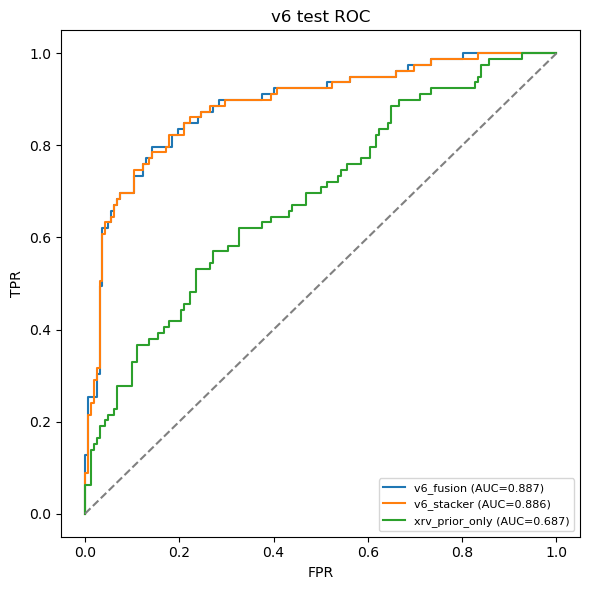

In [23]:
# ---- ROC plot for the top 3 rows ----
plt.figure(figsize=(6, 6))
for name in leaderboard['model'].head(3).tolist() + ['v3', 'v5']:
    if name not in blends: continue
    fpr, tpr, _ = roc_curve(y_te, blends[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_te, blends[name]):.3f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('v6 test ROC')
plt.legend(loc='lower right', fontsize=8); plt.tight_layout()
plt.savefig(RES / 'v6_test_roc.png', dpi=120)
plt.show()

## 10. If the number still isn't where you want it

Diagnostics to consider before more modeling:
1. **Switch label to `outcome_all_pne`** (ICD-based; cleaner than the CheXpert-NLP `Pneumonia` label, which has ~10-15% noise in the literature).
2. **Upgrade the text encoder** to `microsoft/BiomedVLP-CXR-BERT-general` in section 4.1 — it's pretrained on MIMIC-CXR reports specifically.
3. **DeLong's test** between your top-2 models to check whether the difference is statistical or noise.
4. **Unfreeze the text encoder's top 2 layers** and re-fine-tune with a small LR (1e-5) — typically adds 0.01-0.03 at a cost of a longer run.
5. **Report-leakage audit**: some MIMIC-CXR reports directly mention 'pneumonia' by name. Train a second v6 with 'pneumonia'/'pneumonias' scrubbed from the text to verify the model isn't just reading the radiologist's written diagnosis. Report the drop — if the gap is large, that's a valid concern in your methods section.